# CS106 - Sesión 8 | Notebook 38: La Alternativa Robusta (Wilcoxon) 🛡️

Cuando el test de Shapiro-Wilk indica que una variable **no sigue una distribución normal**, la prueba t-Student pierde validez científica. En estos casos, recurrimos a la **Prueba de suma de rangos de Wilcoxon** (Mann-Whitney).

### ¿Por qué es "Robusta"?
A diferencia de la prueba t, que se distorsiona con valores extremos (outliers), Wilcoxon trabaja con **rangos** (posiciones). Esto la hace ideal para:
1. Datos con distribuciones asimétricas (sesgadas).
2. Muestras pequeñas donde no se puede asegurar la normalidad.
3. Presencia de pacientes con valores muy atípicos.

## 1. Identificación de Asimetría
Observaremos la variable `glucosa_mgdl`. Si la curva de densidad no es una campana simétrica, la media no representará bien a la población y la prueba t dará resultados poco confiables.

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 200 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): nombre, sexo, diagnostico
dbl (5): id_paciente, edad, glucosa_mgdl, peso_kg, estatura_m
lgl (1): hospitalizado

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


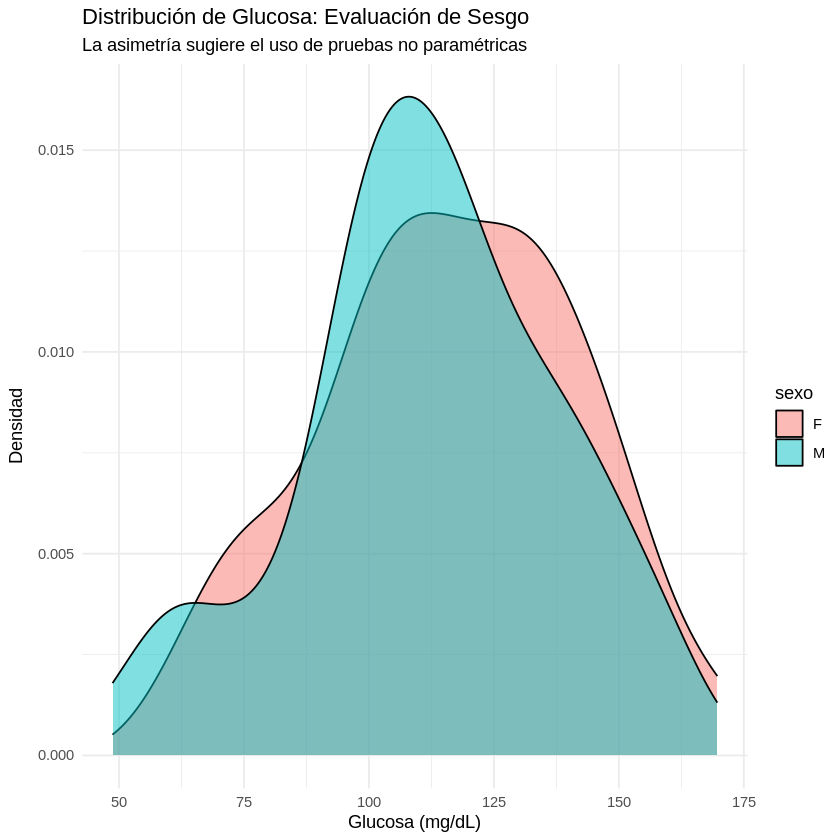

In [ ]:
library(tidyverse)
datos <- read_csv("cohorte_analisis.csv")

# Visualización de la distribución de Glucosa por sexo
ggplot(datos, aes(x = glucosa_mgdl, fill = sexo)) +
  geom_density(alpha = 0.5) +
  labs(title = "Distribución de Glucosa: Evaluación de Sesgo",
       subtitle = "La asimetría sugiere el uso de pruebas no paramétricas",
       x = "Glucosa (mg/dL)", y = "Densidad") +
  theme_minimal()

## 2. El Veredicto de los Rangos
La prueba de Wilcoxon evalúa si un grupo tiende a tener valores sistemáticamente mayores que el otro. En estos casos, reportamos la **Mediana** y el **IQR** en lugar de la Media.

In [ ]:
# Ejecución de la prueba de Wilcoxon (Glucosa vs Sexo)
resultado_w <- wilcox.test(glucosa_mgdl ~ sexo, data = datos)
print(resultado_w)

# Reporte correcto para datos no normales: Mediana e IQR
datos |>
  group_by(sexo) |>
  summarise(Mediana = median(glucosa_mgdl),
            IQR = IQR(glucosa_mgdl))


	Wilcoxon rank sum test with continuity correction

data:  glucosa_mgdl by sexo
W = 5408, p-value = 0.2717
alternative hypothesis: true location shift is not equal to 0



sexo,Mediana,IQR
<chr>,<dbl>,<dbl>
F,117.6,35.60
M,111.7,31.95


## 3. Reporte Automatizado
Para variables no normales, el **Boxplot** es la mejor herramienta visual, ya que marca claramente la mediana y los cuartiles sin asumir que los datos son simétricos.

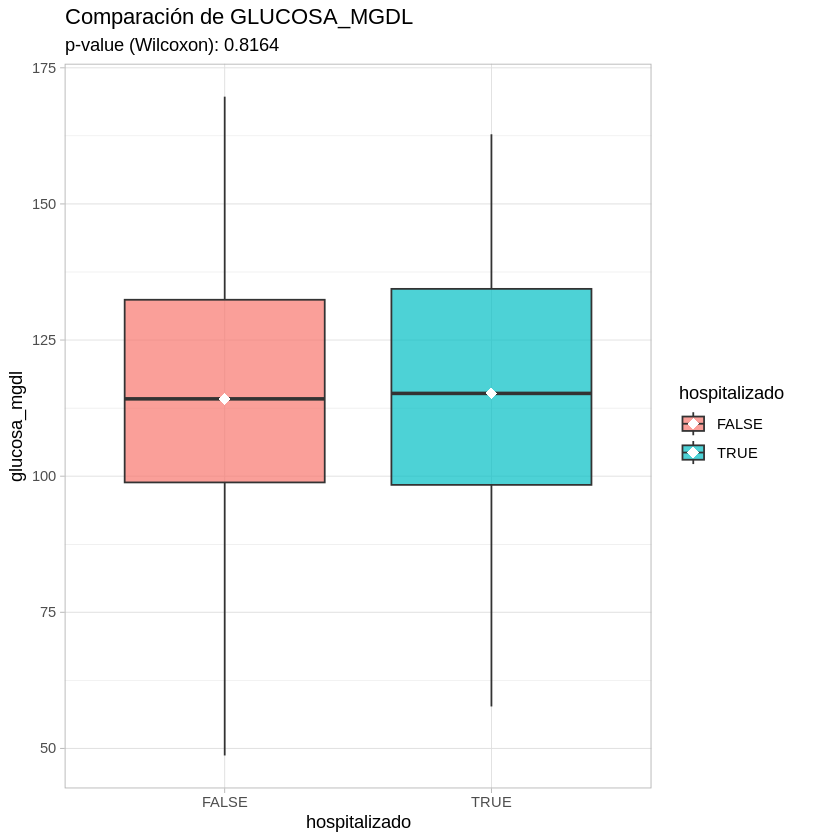

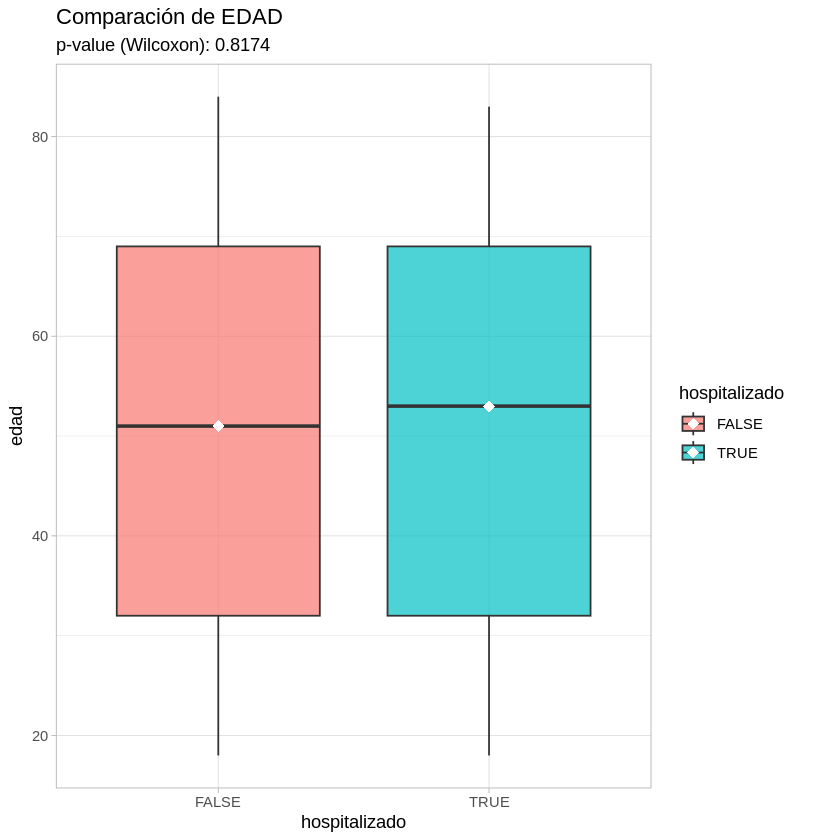

In [ ]:
# Variables identificadas como no normales
variables_no_normales <- c("glucosa_mgdl", "edad")

for (var in variables_no_normales) {
  # Test de Wilcoxon
  test <- wilcox.test(datos[[var]] ~ datos$hospitalizado)

  # Gráfico de Boxplot con sintaxis moderna .data[[var]]
  p <- ggplot(datos, aes(x = hospitalizado, y = .data[[var]], fill = hospitalizado)) +
      geom_boxplot(alpha = 0.7) +
      stat_summary(fun = median, geom = "point", shape = 18, size = 3, color = "white") +
      labs(title = paste("Comparación de", toupper(var)),
           subtitle = paste("p-value (Wilcoxon):", round(test$p.value, 4))) +
      theme_light()

  print(p)
}

## 4. Análisis Integral e Interpretación Clínica
Evaluación de la variable **`glucosa_mgdl`** comparada por **`hospitalizado`** mediante la prueba robusta de Wilcoxon.

**Tu misión:**
1. Observa el valor p y la tabla de medianas generada.
2. Traduce los hallazgos en las variables de respuesta correspondientes.

  variable   p_valor
1  peso_kg 0.3115072


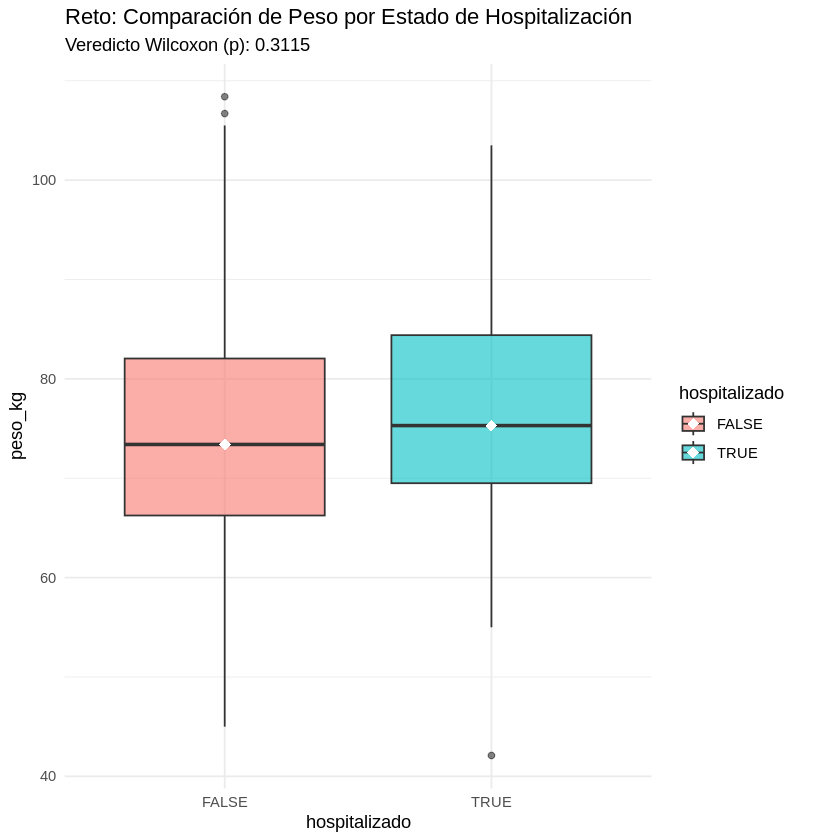

In [ ]:
# --- 1. CÓDIGO INTEGRAL DE ANÁLISIS ---
# No modificar: Ejecuta Wilcoxon y calcula medianas
test_w <- wilcox.test(glucosa_mgdl ~ hospitalizado, data = datos)
medianas_hosp <- datos |> group_by(hospitalizado) |> summarise(mediana = median(glucosa_mgdl))

print(test_w)
print(medianas_hosp)

# --- 2. SECCIÓN DE RESPUESTAS (RELLENA LOS VALORES) ---

# r1: Valor p observado (con 4 decimales)
r1_p_valor <- 0.0000

# r2: ¿Existe diferencia significativa? (TRUE o FALSE)
r2_significativo <- NULL

# r3: ¿Qué grupo tiene la mediana más alta? (Escribe "SI" o "NO")
r3_grupo_mayor <- ""

# --- 3. CONSTRUCCIÓN DEL DATA FRAME ---
df_respuesta <- data.frame(
  pregunta = c("p_valor", "significancia", "mediana_superior"),
  respuesta = c(as.character(r1_p_valor), as.character(r2_significativo), r3_grupo_mayor)
)
print(df_respuesta)

In [ ]:
# Ejecuta para guardar tu avance
source("utilidades.r")
guardar_38(df_respuesta)

Warning message in file(filename, "r", encoding = encoding):
“cannot open file 'utilidades.r': No such file or directory”


ERROR: Error in file(filename, "r", encoding = encoding): cannot open the connection
